In [2]:
import findspark
findspark.init()
import pyspark

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc


In [4]:

spark = SparkSession.builder \
    .appName("Churn Prediction with PySpark MLlib") \
    .getOrCreate()
print("Spark Session created successfully.")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/09 11:42:33 WARN Utils: Your hostname, JeffLaptop, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/04/09 11:42:33 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/09 11:42:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Session created successfully.


In [5]:
df = spark.read.csv("Churn_Modelling.csv", header=True, inferSchema=True)
print(f"Data loaded with {df.count():,} rows and {len(df.columns)} columns.")
print("\nDF Schema:")
df.printSchema()
print("\nFirst 10 rows:")
df.show(10)

Data loaded with 10,000 rows and 14 columns.

DF Schema:
root
 |-- RowNumber: integer (nullable = true)
 |-- CustomerId: integer (nullable = true)
 |-- Surname: string (nullable = true)
 |-- CreditScore: integer (nullable = true)
 |-- Geography: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Tenure: integer (nullable = true)
 |-- Balance: double (nullable = true)
 |-- NumOfProducts: integer (nullable = true)
 |-- HasCrCard: integer (nullable = true)
 |-- IsActiveMember: integer (nullable = true)
 |-- EstimatedSalary: double (nullable = true)
 |-- Exited: integer (nullable = true)


First 10 rows:
+---------+----------+--------+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|RowNumber|CustomerId| Surname|CreditScore|Geography|Gender|Age|Tenure|  Balance|NumOfProducts|HasCrCard|IsActiveMember|EstimatedSalary|Exited|
+---------+----------+--------+-----------+--------

In [6]:
print("\nEDA: Stats")
number_cols = [col for col, dtype in df.dtypes if dtype in ['int', 'double']]
stat_df = df.select(number_cols).summary("count","mean","stddev","min","25%","50%","75%","max")
stat_pd = stat_df.toPandas()
print(stat_pd.to_string(index=False))
print("\nMissing Values:")
for col in df.columns:
    missing = df.filter(F.col(col).isNull()).count()
    print(f"{col}: {missing} missing values")




EDA: Stats


26/04/09 11:42:39 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


summary          RowNumber        CustomerId       CreditScore                Age             Tenure           Balance      NumOfProducts           HasCrCard      IsActiveMember   EstimatedSalary              Exited
  count              10000             10000             10000              10000              10000             10000              10000               10000               10000             10000               10000
   mean             5000.5   1.56909405694E7          650.5288            38.9218             5.0128 76485.88928799961             1.5302              0.7055              0.5151 100090.2398809998              0.2037
 stddev 2886.8956799071675 71936.18612274907 96.65329873613035 10.487806451704587 2.8921743770496837 62397.40520238599 0.5816543579989917 0.45584046447513327 0.49979692845891815 57510.49281769821 0.40276858399486065
    min                  1          15565701               350                 18                  0               0.0                  


Churn Breakdown:
 Exited  count
      1   2037
      0   7963


/tmp/ipykernel_18080/2033295224.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn, x='Exited', y='count', ax=axes[1], palette=colors)


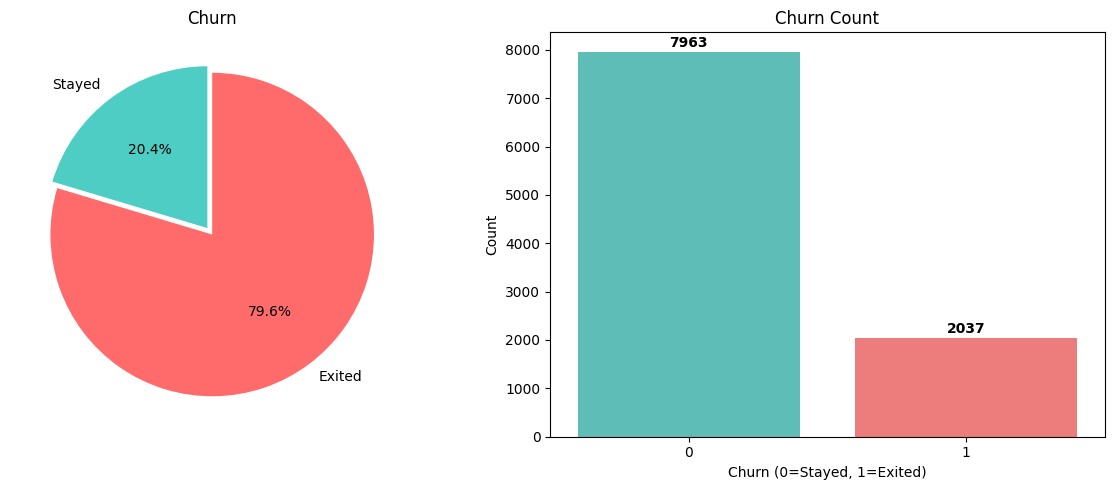

In [7]:
print("\nChurn Breakdown:")
churn = df.groupBy("Exited").count().toPandas()
print(churn.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4ECDC4', '#FF6B6B']
label = ['Stayed', 'Exited']
axes[0].pie(churn['count'], labels=label, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0))
axes[0].set_title("Churn")
sns.barplot(data=churn, x='Exited', y='count', ax=axes[1], palette=colors)
axes[1].set_title("Churn Count")
axes[1].set_xlabel('Churn (0=Stayed, 1=Exited)')
axes[1].set_ylabel('Count')
for x, y in zip(churn['Exited'], churn['count']):
    axes[1].text(x, y + 100, str(y), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


Churn Feature Analysis:

RowNumber:
 Exited        mean      stddev  count
      1 4905.917526 2866.855245      1
      0 5024.694964 2891.682053      2

CustomerId:
 Exited         mean       stddev    count
      1 1.569005e+07 72692.623920 15565706
      0 1.569117e+07 71744.234941 15565701

CreditScore:
 Exited       mean     stddev  count
      1 645.351497 100.321503    350
      0 651.853196  95.653837    405

Age:
 Exited      mean    stddev  count
      1 44.837997  9.761562     18
      0 37.408389 10.125363     18

Tenure:
 Exited     mean   stddev  count
      1 4.932744 2.936106      0
      0 5.033279 2.880658      0

Balance:
 Exited         mean       stddev  count
      1 91108.539337 58360.794816    0.0
      0 72745.296779 62848.040701    0.0

NumOfProducts:
 Exited     mean   stddev  count
      1 1.475209 0.801521      1
      0 1.544267 0.509536      1

HasCrCard:
 Exited     mean   stddev  count
      1 0.699067 0.458776      0
      0 0.707146 0.455101      0



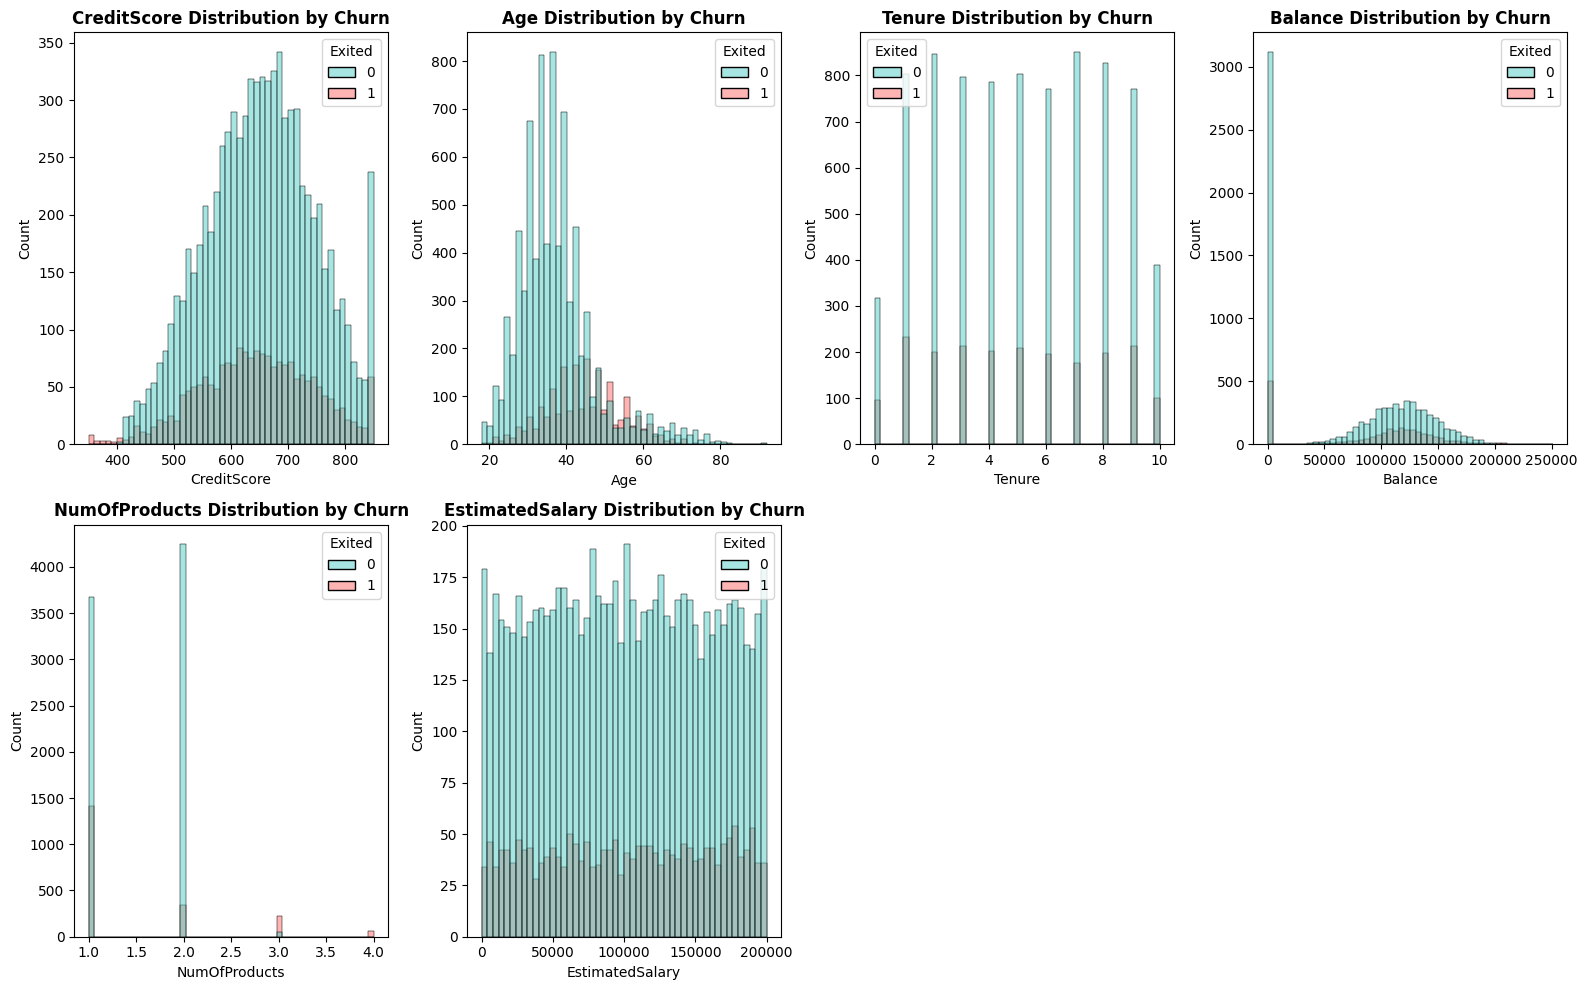

In [8]:
print("\nChurn Feature Analysis:")
for col in number_cols[:-1]:
    print(f"\n{col}:")
    churn_stats = df.groupBy("Exited").agg(
        F.mean(col).alias("mean"),
        F.stddev(col).alias("stddev"),
        F.min(col).alias("count")
    ).toPandas()
    print(churn_stats.to_string(index=False))
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()
col_plots = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
for idx, col in enumerate(col_plots):
    df_pd = df.select(col, "Exited").toPandas()
    sns.histplot(data=df_pd, x=col, hue='Exited', bins=50, alpha=0.5, ax=axes[idx], palette=colors)
    axes[idx].set_title(f'{col} Distribution by Churn', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
for idx in range(len(col_plots), len(axes)):
    axes[idx].remove()
plt.tight_layout()
plt.show()


Categorical Churn Analysis:

Geography Churn Rates:
Exited        0    1  Churn Rate
Geography                       
France     4204  810   16.154767
Germany    1695  814   32.443204
Spain      2064  413   16.673395

Gender Churn Rates:
Exited     0     1  Churn Rate
Gender                        
Female  3404  1139   25.071539
Male    4559   898   16.455928


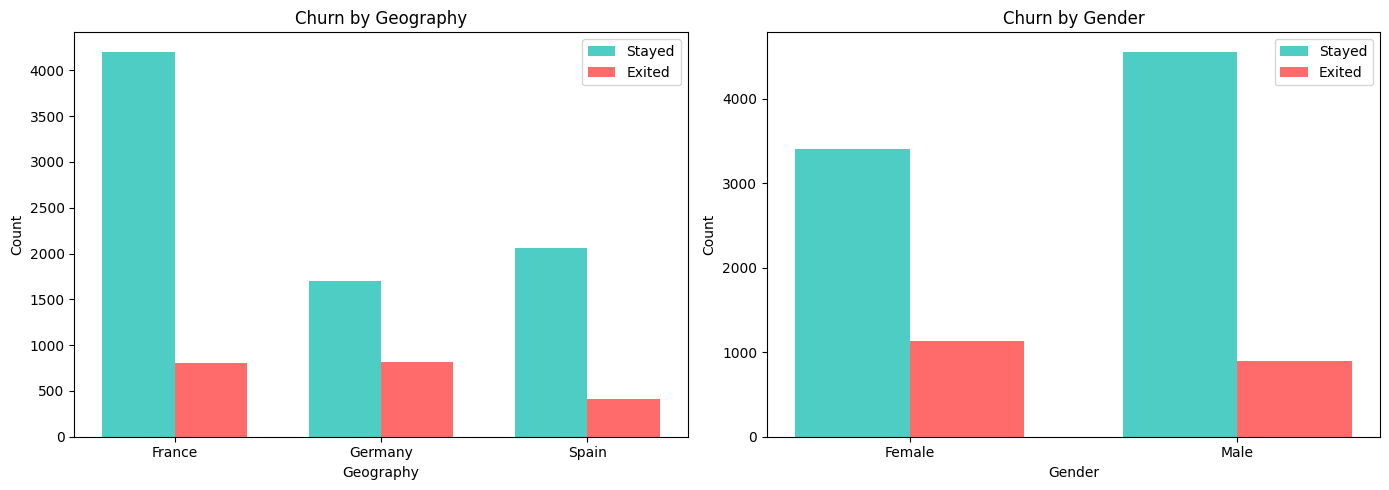

In [9]:
print("\nCategorical Churn Analysis:")
geography = df.groupBy("Geography", 'Exited').count().toPandas()
geography_pivot = geography.pivot(index='Geography', columns="Exited", values='count').fillna(0)
geography_pivot['Churn Rate'] = geography_pivot[1] / (geography_pivot[0] + geography_pivot[1]) * 100
print('\nGeography Churn Rates:')
print(geography_pivot)
gender = df.groupBy("Gender", "Exited").count().toPandas()
gender_pivot = gender.pivot(index='Gender', columns='Exited', values='count').fillna(0)
gender_pivot['Churn Rate'] = gender_pivot[1] / (gender_pivot[0] + gender_pivot[1]) * 100
print('\nGender Churn Rates:')
print(gender_pivot)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
geo_data = geography_pivot.reset_index()
x = np.arange(len(geo_data['Geography']))
width = 0.35
axes[0].bar(x - width/2, geo_data[0], width, label='Stayed', color = '#4ECDC4')
axes[0].bar(x + width/2, geo_data[1], width, label='Exited', color = '#FF6B6B')
axes[0].set_xlabel('Geography')
axes[0].set_ylabel('Count')
axes[0].set_title('Churn by Geography')
axes[0].set_xticks(x)
axes[0].set_xticklabels(geo_data['Geography'])
axes[0].legend()

gender_data = gender_pivot.reset_index()
x = np.arange(len(gender_data['Gender']))
width = 0.35
axes[1].bar(x - width/2, gender_data[0], width, label='Stayed', color = '#4ECDC4')
axes[1].bar(x + width/2, gender_data[1], width, label='Exited', color = '#FF6B6B')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].set_title('Churn by Gender')
axes[1].set_xticks(x)
axes[1].set_xticklabels(gender_data['Gender'])
axes[1].legend()
plt.tight_layout()
plt.show()


Age Group Churn Rates:
Exited       0    1  Churn Rate
AgeGroup                       
18-29     1517  124    7.556368
30-39     3873  473   10.883571
40-49     1812  806   30.786860
50-59      382  487   56.041427
60-69      243  132   35.200000
70+        136   15    9.933775

Balance and Salary Churn:
   Exited  mean_balaance    mean_salary
0       1   91108.539337  101465.677531
1       0   72745.296779   99738.391772


/tmp/ipykernel_18080/49457510.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=age_data, x='Exited', y='Age', ax=axes[1], palette=colors)


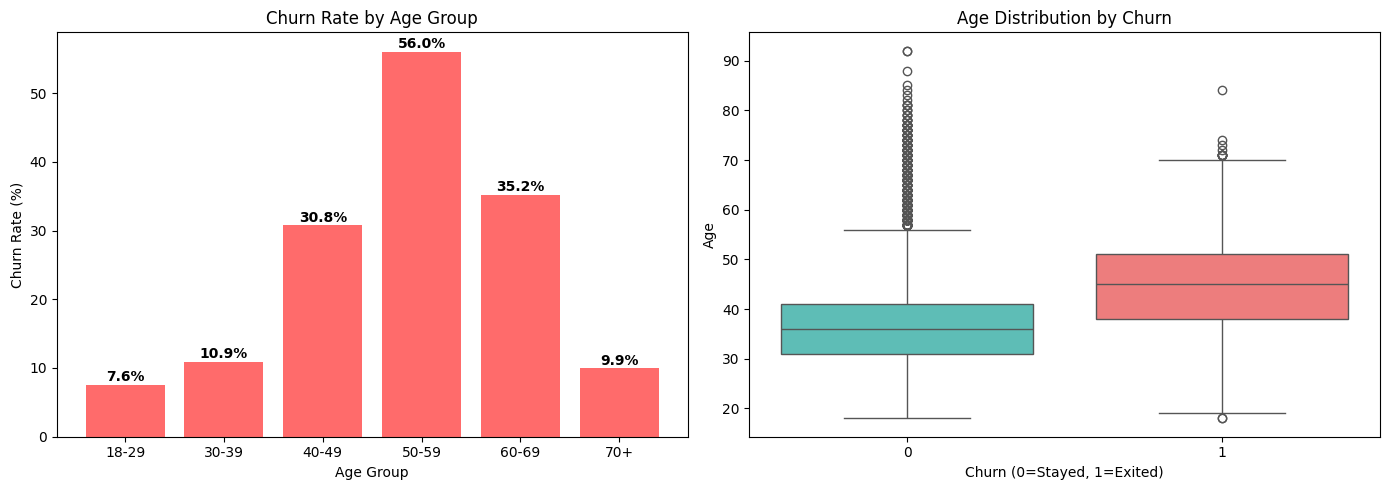

In [10]:
ages = [18, 30,40,50,60,100]
age_label = ['18-29','30-39','40-49','50-59','60-69','70+']
age_df = df.withColumn("AgeGroup",
    F.when(F.col("Age")<30, age_label[0])
    .when(F.col("Age")<40, age_label[1])
    .when(F.col("Age")<50, age_label[2])
    .when(F.col("Age")<60, age_label[3])
    .when(F.col("Age")<70, age_label[4])
    .otherwise(age_label[5]))
age_churn = age_df.groupBy("AgeGroup", "Exited").count().toPandas()
age_churn_pivot = age_churn.pivot(index='AgeGroup', columns='Exited', values='count').fillna(0)
age_churn_pivot['Churn Rate'] = age_churn_pivot[1] / (age_churn_pivot[0] + age_churn_pivot[1]) * 100
print('\nAge Group Churn Rates:')
print(age_churn_pivot.sort_index())

balance_churn = df.groupBy("Exited").agg(
    F.mean("Balance").alias("mean_balaance"),
    F.mean("EstimatedSalary").alias("mean_salary")
).toPandas()
print("\nBalance and Salary Churn:")
print(balance_churn)

fig, axes = plt.subplots(1,2,figsize=(14,5))
age_churn_data = age_churn_pivot.reset_index()
axes[0].bar(age_churn_data['AgeGroup'], age_churn_data['Churn Rate'], color='#FF6B6B')
axes[0].set_title('Churn Rate by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Churn Rate (%)')
for x, y in zip(age_churn_data['AgeGroup'], age_churn_data['Churn Rate']):
    axes[0].text(x, y + 0.5, f'{y:.1f}%', ha='center', fontweight='bold')

age_data = df.select("Age", "Exited").toPandas()
sns.boxplot(data=age_data, x='Exited', y='Age', ax=axes[1], palette=colors)
axes[1].set_title('Age Distribution by Churn')
axes[1].set_xlabel('Churn (0=Stayed, 1=Exited)')
axes[1].set_ylabel('Age')
plt.tight_layout()
plt.show()


Product Usage and Churn:
Exited              0       1  Churn Rate
NumOfProducts                            
1              3675.0  1409.0   27.714398
2              4242.0   348.0    7.581699
3                46.0   220.0   82.706767
4                 0.0    60.0  100.000000

Active Member Churn Rates:
Exited             0     1  Churn Rate
IsActiveMember                        
0               3547  1302   26.850897
1               4416   735   14.269074

Credit Card Churn Rates:
Exited        0     1  Churn Rate
HasCrCard                        
0          2332   613   20.814941
1          5631  1424   20.184266


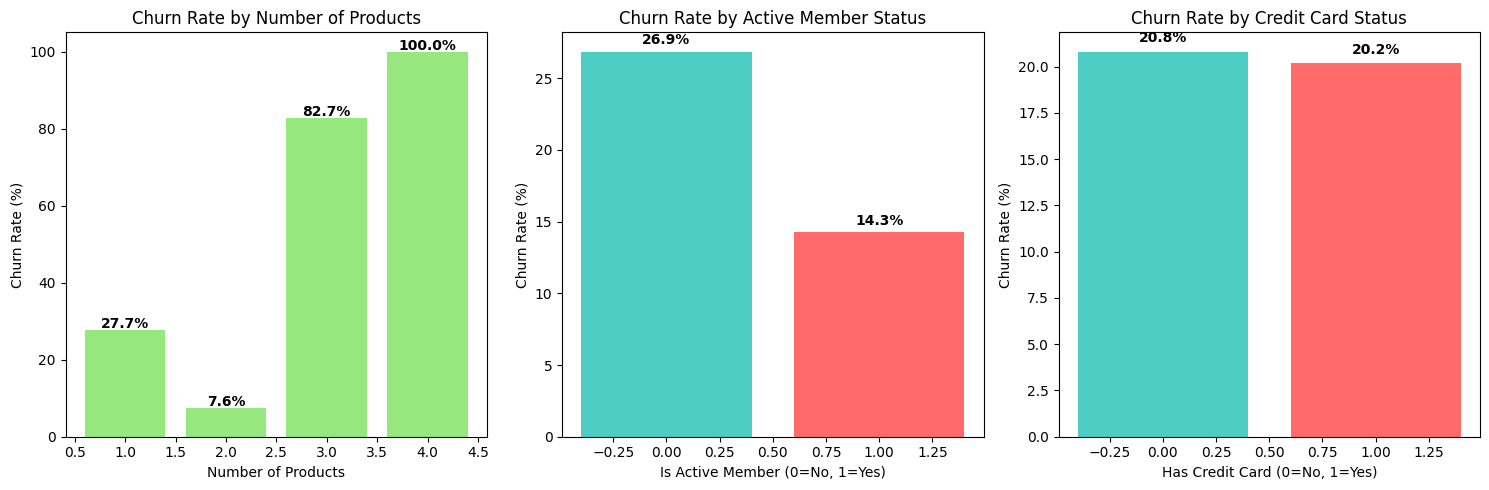

In [11]:
print("\nProduct Usage and Churn:")
product_churn = df.groupBy("NumOfProducts", "Exited").count().toPandas()
product_churn_pivot = product_churn.pivot(index='NumOfProducts', columns='Exited', values='count').fillna(0)
product_churn_pivot['Churn Rate'] = product_churn_pivot[1] / (product_churn_pivot[0] + product_churn_pivot[1]) * 100
print(product_churn_pivot.sort_index())

active_churn = df.groupBy("IsActiveMember", "Exited").count().toPandas()
active_churn_pivot = active_churn.pivot(index='IsActiveMember', columns='Exited', values='count').fillna(0)
active_churn_pivot['Churn Rate'] = active_churn_pivot[1] / (active_churn_pivot[0] + active_churn_pivot[1]) * 100
print("\nActive Member Churn Rates:")
print(active_churn_pivot)

card_churn = df.groupBy("HasCrCard", "Exited").count().toPandas()
card_churn_pivot = card_churn.pivot(index='HasCrCard', columns='Exited', values='count').fillna(0)
card_churn_pivot['Churn Rate'] = card_churn_pivot[1] / (card_churn_pivot[0] + card_churn_pivot[1]) * 100
print("\nCredit Card Churn Rates:")
print(card_churn_pivot)

fig, axes = plt.subplots(1,3,figsize=(15,5))
product_data = product_churn_pivot.reset_index()
axes[0].bar(product_data['NumOfProducts'], product_data['Churn Rate'], color='#95E77E')
axes[0].set_title('Churn Rate by Number of Products')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Churn Rate (%)')
for x, y in zip(product_data['NumOfProducts'], product_data['Churn Rate']):
    axes[0].text(x, y + 0.5, f'{y:.1f}%', ha='center', fontweight='bold')
active_data = active_churn_pivot.reset_index()
axes[1].bar(active_data['IsActiveMember'], active_data['Churn Rate'], color=['#4ECDC4','#FF6B6B'])
axes[1].set_title('Churn Rate by Active Member Status')
axes[1].set_xlabel('Is Active Member (0=No, 1=Yes)')
axes[1].set_ylabel('Churn Rate (%)')
for x, y in zip(active_data['IsActiveMember'], active_data['Churn Rate']):
    axes[1].text(x, y + 0.5, f'{y:.1f}%', ha='center', fontweight='bold')
card_data = card_churn_pivot.reset_index()
axes[2].bar(card_data['HasCrCard'], card_data['Churn Rate'], color=['#4ECDC4','#FF6B6B'])
axes[2].set_title('Churn Rate by Credit Card Status')
axes[2].set_xlabel('Has Credit Card (0=No, 1=Yes)')
axes[2].set_ylabel('Churn Rate (%)')
for x, y in zip(card_data['HasCrCard'], card_data['Churn Rate']):
    axes[2].text(x, y + 0.5, f'{y:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()  


Tenure and Churn:
Exited    0    1  Churn Rate
Tenure                      
0       318   95   23.002421
1       803  232   22.415459
2       847  201   19.179389
3       796  213   21.110010
4       786  203   20.525784
5       803  209   20.652174
6       771  196   20.268873
7       851  177   17.217899
8       828  197   19.219512
9       771  213   21.646341
10      389  101   20.612245


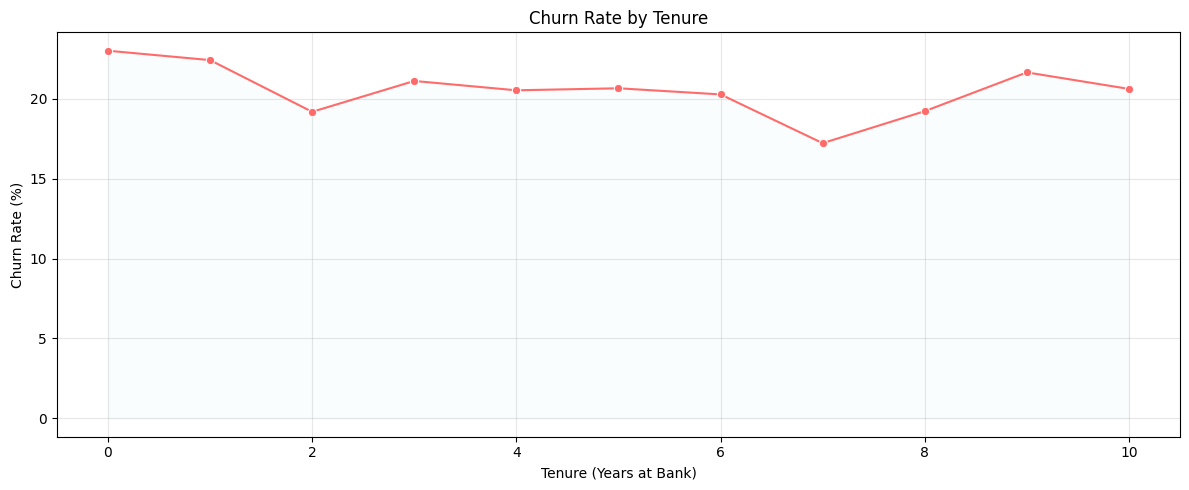

In [12]:
print("\nTenure and Churn:")
tenure_churn = df.groupBy("Tenure", "Exited").count().toPandas()
tenure_churn_pivot = tenure_churn.pivot(index='Tenure', columns='Exited', values='count').fillna(0)
tenure_churn_pivot['Churn Rate'] = tenure_churn_pivot[1] / (tenure_churn_pivot[0] + tenure_churn_pivot[1]) * 100
print(tenure_churn_pivot.sort_index())

tenure_rate = tenure_churn_pivot.reset_index()
plt.figure(figsize=(12,5))
sns.lineplot(data=tenure_rate, x='Tenure', y='Churn Rate', marker='o', color='#FF6B6B')
plt.fill_between(tenure_rate['Tenure'],0,tenure_rate['Churn Rate'], alpha=0.03, color='#4ECDC4')
plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure (Years at Bank)')
plt.ylabel('Churn Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
print("\nData Prep for Modeling:")
df_model = df.drop("RowNumber","CustomerId","Surname")
categorical_cols = [col for col, dtype in df_model.dtypes if dtype == 'string']
numerical_cols = [col for col, dtype in df_model.dtypes if dtype in ['int', 'double'] and col != 'Exited']
print(f"Categorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numerical_cols}")
print("Target Column: Exited")

print("\nClass Distribution:")
df_model.groupBy("Exited").count().show()



Data Prep for Modeling:
Categorical Columns: ['Geography', 'Gender']
Numerical Columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Target Column: Exited

Class Distribution:
+------+-----+
|Exited|count|
+------+-----+
|     1| 2037|
|     0| 7963|
+------+-----+



In [14]:
indexers = [StringIndexer(inputCol=col, outputCol=col + "_index", handleInvalid="keep") 
            for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=col + "_index", outputCol=col + "_encoded") 
            for col in categorical_cols]

feature_cols = numerical_cols + [col + "_encoded" for col in categorical_cols]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")

scaler = StandardScaler(inputCol="features_raw", outputCol="features", 
                        withStd=True, withMean=True)

lr = LogisticRegression(featuresCol="features", labelCol="Exited", 
                        family="binomial")
stages = indexers + encoders + [assembler, scaler, lr]
pipeline = Pipeline(stages=stages)

print("Pipeline stages:")
for i, stage in enumerate(pipeline.getStages()):
    print(f"  Stage {i+1}: {stage.__class__.__name__}")

Pipeline stages:
  Stage 1: StringIndexer
  Stage 2: StringIndexer
  Stage 3: OneHotEncoder
  Stage 4: OneHotEncoder
  Stage 5: VectorAssembler
  Stage 6: StandardScaler
  Stage 7: LogisticRegression


In [15]:
train_df, test_df = df_model.randomSplit([0.7, 0.3], seed=42)

print(f"Training set size: {train_df.count():,}")
print(f"Test set size: {test_df.count():,}")
print(f"\nTraining set class distribution:")
train_df.groupBy("Exited").count().show()
print(f"\nTest set class distribution:")
test_df.groupBy("Exited").count().show()

Training set size: 7,104
Test set size: 2,896

Training set class distribution:
+------+-----+
|Exited|count|
+------+-----+
|     1| 1433|
|     0| 5671|
+------+-----+


Test set class distribution:
+------+-----+
|Exited|count|
+------+-----+
|     1|  604|
|     0| 2292|
+------+-----+



In [16]:
print("\nHyperparameter Tuning:")
paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.001, 0.01, 0.1, 1.0]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .addGrid(lr.maxIter, [50, 100]) \
    .addGrid(lr.threshold, [0.3, 0.5, 0.7]) \
    .build()

print(f"Parameter combinations: {len(paramGrid)}")

evaluator = MulticlassClassificationEvaluator(
    labelCol="Exited", predictionCol="prediction", metricName="accuracy")

crossval = CrossValidator(estimator=pipeline,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=5,
                          seed=42,
                          parallelism=4)

print("Starting cross-validation training...")
print(f"Total models to train: {len(paramGrid) * 5}")

cv_model = crossval.fit(train_df)
best_model = cv_model.bestModel

print("\nBest Hyperparameters:")
print(f"regParam: {best_model.stages[-1]._java_obj.getRegParam()}")
print(f"elasticNetParam: {best_model.stages[-1]._java_obj.getElasticNetParam()}")
print(f"maxIter: {best_model.stages[-1]._java_obj.getMaxIter()}")
print(f"threshold: {best_model.stages[-1]._java_obj.getThreshold()}")
print(f"\nBest cross-validation accuracy: {max(cv_model.avgMetrics):.4f}")


Hyperparameter Tuning:
Parameter combinations: 72
Starting cross-validation training...
Total models to train: 360


26/04/09 11:42:47 WARN BlockManager: Block rdd_320_0 already exists on this machine; not re-adding it
26/04/09 11:42:47 WARN BlockManager: Block rdd_320_0 already exists on this machine; not re-adding it
26/04/09 11:42:49 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/09 11:42:50 WARN BlockManager: Block rdd_661_0 already exists on this machine; not re-adding it
26/04/09 11:42:50 WARN BlockManager: Block rdd_661_0 already exists on this machine; not re-adding it



Best Hyperparameters:
regParam: 0.01
elasticNetParam: 0.5
maxIter: 50
threshold: 0.5

Best cross-validation accuracy: 0.8097


In [17]:
print("\nModel Evaluation:")
test_predictions = best_model.transform(test_df)
accuracy = evaluator.evaluate(test_predictions)
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="Exited", predictionCol="prediction", metricName="precisionByLabel", metricLabel=1)
precision = precision_evaluator.evaluate(test_predictions)
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="Exited", predictionCol="prediction", metricName="recallByLabel", metricLabel=1)
recall = recall_evaluator.evaluate(test_predictions)
# Weighted F1-score (overall)
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="Exited", predictionCol="prediction", metricName="f1")
f1_score = f1_evaluator.evaluate(test_predictions)
# F1-score for label 1 (churned)
f1_label1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (label 1): {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall (label 1):    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score (weighted):  {f1_score:.4f} ({f1_score*100:.2f}%)")
print(f"F1-Score (label 1):   {f1_label1:.4f} ({f1_label1*100:.2f}%)")



Model Evaluation:
Accuracy:  0.8142 (81.42%)
Precision (label 1): 0.7012 (70.12%)
Recall (label 1):    0.1904 (19.04%)
F1-Score (weighted):  0.7691 (76.91%)
F1-Score (label 1):   0.2995 (29.95%)


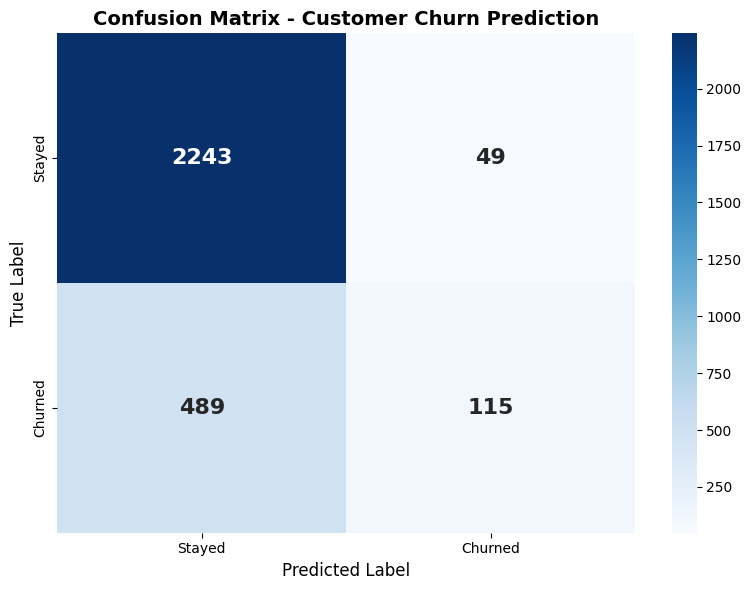


Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.98      0.89      2292
     Churned       0.70      0.19      0.30       604

    accuracy                           0.81      2896
   macro avg       0.76      0.58      0.60      2896
weighted avg       0.80      0.81      0.77      2896


Confusion Matrix Values:
  True Negatives (Correctly predicted stayed): 2,243
  False Positives (Wrongly predicted churned): 49
  False Negatives (Wrongly predicted stayed): 489
  True Positives (Correctly predicted churned): 115


In [18]:
predictions_pd = test_predictions.select("Exited", "prediction").toPandas()
cm = confusion_matrix(predictions_pd['Exited'], predictions_pd['prediction'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            annot_kws={'size': 16, 'weight': 'bold'})
plt.title('Confusion Matrix - Customer Churn Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(predictions_pd['Exited'], predictions_pd['prediction'],
                            target_names=['Stayed', 'Churned']))

print(f"\nConfusion Matrix Values:")
print(f"  True Negatives (Correctly predicted stayed): {cm[0,0]:,}")
print(f"  False Positives (Wrongly predicted churned): {cm[0,1]:,}")
print(f"  False Negatives (Wrongly predicted stayed): {cm[1,0]:,}")
print(f"  True Positives (Correctly predicted churned): {cm[1,1]:,}")


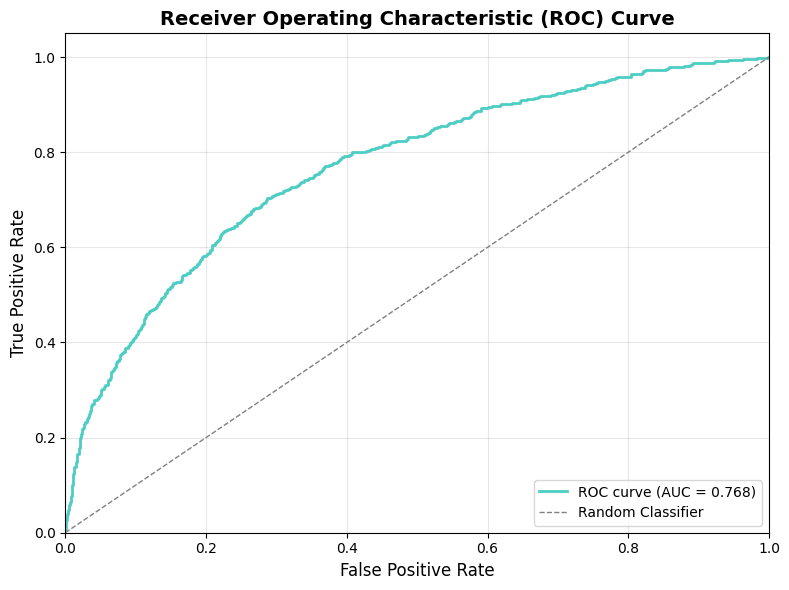

Area Under ROC Curve (AUC): 0.7681


In [19]:
probabilities_pd = test_predictions.select("probability", "Exited").toPandas()
probabilities_pd['probability_positive'] = probabilities_pd['probability'].apply(lambda x: x[1])
fpr, tpr, thresholds = roc_curve(probabilities_pd['Exited'], probabilities_pd['probability_positive'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#4ECDC4', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Area Under ROC Curve (AUC): {roc_auc:.4f}")

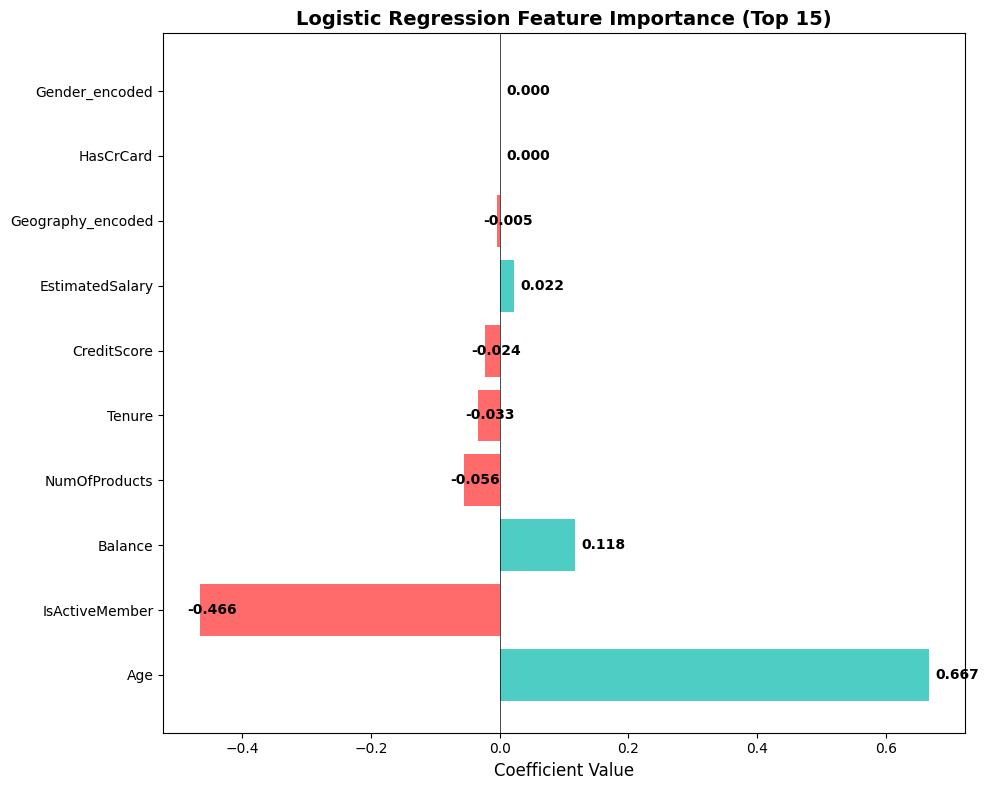


Model Intercept: -1.6010

Top 10 Most Important Features:
  Age: coefficient = 0.6670 (Positive impact)
  IsActiveMember: coefficient = -0.4663 (Negative impact)
  Balance: coefficient = 0.1177 (Positive impact)
  NumOfProducts: coefficient = -0.0561 (Negative impact)
  Tenure: coefficient = -0.0330 (Negative impact)
  CreditScore: coefficient = -0.0235 (Negative impact)
  EstimatedSalary: coefficient = 0.0216 (Positive impact)
  Geography_encoded: coefficient = -0.0049 (Negative impact)
  HasCrCard: coefficient = 0.0000 (Negative impact)
  Gender_encoded: coefficient = 0.0000 (Negative impact)


In [20]:
coefficients = best_model.stages[-1].coefficients
intercept = best_model.stages[-1].intercept

# Get the actual feature names from the VectorAssembler
vector_assembler = best_model.stages[4]  # VectorAssembler is at index 4
input_cols = vector_assembler.getInputCols()

feature_importance = pd.DataFrame({
    'Feature': input_cols,
    'Coefficient': coefficients.toArray().flatten()[:len(input_cols)]
})
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)
feature_importance['Impact'] = feature_importance['Coefficient'].apply(
    lambda x: 'Positive' if x > 0 else 'Negative')

plt.figure(figsize=(10, 8))
colors_imp = ['#4ECDC4' if x > 0 else '#FF6B6B' for x in feature_importance['Coefficient']]
bars = plt.barh(feature_importance['Feature'][:15], feature_importance['Coefficient'][:15], color=colors_imp)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Logistic Regression Feature Importance (Top 15)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

for bar, val in zip(bars, feature_importance['Coefficient'][:15]):
    plt.text(val + (0.01 if val >= 0 else -0.02), bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nModel Intercept: {intercept:.4f}")
print("\nTop 10 Most Important Features:")
for _, row in feature_importance.head(10).iterrows():
    print(f"  {row['Feature']}: coefficient = {row['Coefficient']:.4f} ({row['Impact']} impact)")


Learning Curve Analysis:


Training size:  10% - Train Acc: 0.8039, Val Acc: 0.8118
Training size:  20% - Train Acc: 0.7957, Val Acc: 0.8194
Training size:  30% - Train Acc: 0.7997, Val Acc: 0.8201
Training size:  40% - Train Acc: 0.8036, Val Acc: 0.8191
Training size:  50% - Train Acc: 0.8028, Val Acc: 0.8180
Training size:  60% - Train Acc: 0.8036, Val Acc: 0.8170
Training size:  70% - Train Acc: 0.8033, Val Acc: 0.8173
Training size:  80% - Train Acc: 0.8053, Val Acc: 0.8170
Training size:  90% - Train Acc: 0.8095, Val Acc: 0.8142


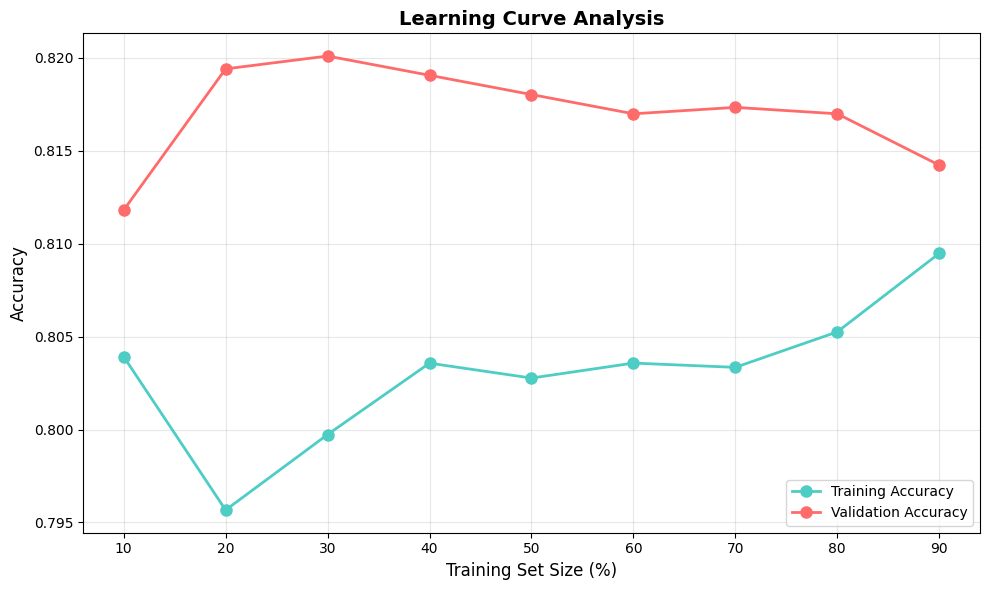


Average overfitting gap: -0.0141
Model generalizes well (minimal overfitting)


In [21]:
print("\nLearning Curve Analysis:")

train_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
train_scores = []
val_scores = []

best_regParam = best_model.stages[-1]._java_obj.getRegParam()
best_elasticNet = best_model.stages[-1]._java_obj.getElasticNetParam()
best_maxIter = best_model.stages[-1]._java_obj.getMaxIter()
best_threshold = best_model.stages[-1]._java_obj.getThreshold()

lr_tuned = LogisticRegression(featuresCol="features", labelCol="Exited",
                               regParam=best_regParam,
                               elasticNetParam=best_elasticNet,
                               maxIter=best_maxIter,
                               threshold=best_threshold)

pipeline_tuned = Pipeline(stages=indexers + encoders + [assembler, scaler, lr_tuned])

for size in train_sizes:
    sample_train_df = train_df.sample(withReplacement=False, fraction=size, seed=42)
    
    model_tuned = pipeline_tuned.fit(sample_train_df)
    
    train_pred = model_tuned.transform(sample_train_df)
    train_acc = evaluator.evaluate(train_pred)
    train_scores.append(train_acc)
    
    val_pred = model_tuned.transform(test_df)
    val_acc = evaluator.evaluate(val_pred)
    val_scores.append(val_acc)
    
    print(f"Training size: {size*100:3.0f}% - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot([s*100 for s in train_sizes], train_scores, 'o-', label='Training Accuracy', 
         color='#4ECDC4', linewidth=2, markersize=8)
plt.plot([s*100 for s in train_sizes], val_scores, 'o-', label='Validation Accuracy', 
         color='#FF6B6B', linewidth=2, markersize=8)
plt.xlabel('Training Set Size (%)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Learning Curve Analysis', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

overfitting_gap = np.mean([train_scores[i] - val_scores[i] for i in range(len(train_scores))])
print(f"\nAverage overfitting gap: {overfitting_gap:.4f}")
if overfitting_gap > 0.05:
    print("Warning: Potential overfitting detected")
else:
    print("Model generalizes well (minimal overfitting)")


In [22]:
print("\nFinal Summary:")

print("\nDataset Info:")
print(f"   Total samples: {df.count():,}")
print(f"   Features used: {len(numerical_cols)} numerical + {len(categorical_cols)} categorical")
print(f"   Training samples: {train_df.count():,}")
print(f"   Test samples: {test_df.count():,}")

print("\nModel Performance::")
print(f"   Best CV Accuracy: {max(cv_model.avgMetrics):.4f}")
print(f"   Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Test Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   Test Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"   Test F1-Score: {f1_score:.4f} ({f1_score*100:.2f}%)")
print(f"   ROC-AUC Score: {roc_auc:.4f}")

print("\nBest Hyperparameters::")
print(f"   Regularization Parameter (regParam): {best_regParam}")
print(f"   Elastic Net Parameter (elasticNetParam): {best_elasticNet}")
print(f"   Max Iterations (maxIter): {best_maxIter}")
print(f"   Threshold: {best_threshold}")

print("\nConfusion Matrix:")
print(f"   True Negatives (Correctly predicted stayed): {cm[0,0]:,}")
print(f"   False Positives (Wrongly predicted churned): {cm[0,1]:,}")
print(f"   False Negatives (Wrongly predicted stayed): {cm[1,0]:,}")
print(f"   True Positives (Correctly predicted churned): {cm[1,1]:,}")

print("\nInsights:")
print(f"   Most important feature: {feature_importance.iloc[0]['Feature']} (coef: {feature_importance.iloc[0]['Coefficient']:.4f})")
print(f"   Second most important: {feature_importance.iloc[1]['Feature']} (coef: {feature_importance.iloc[1]['Coefficient']:.4f})")
print(f"   Third most important: {feature_importance.iloc[2]['Feature']} (coef: {feature_importance.iloc[2]['Coefficient']:.4f})")

print("\nSummary complete.")



Final Summary:

Dataset Info:
   Total samples: 10,000
   Features used: 8 numerical + 2 categorical
   Training samples: 7,104
   Test samples: 2,896

Model Performance::
   Best CV Accuracy: 0.8097
   Test Accuracy: 0.8142 (81.42%)
   Test Precision: 0.7012 (70.12%)
   Test Recall: 0.1904 (19.04%)
   Test F1-Score: 0.7691 (76.91%)
   ROC-AUC Score: 0.7681

Best Hyperparameters::
   Regularization Parameter (regParam): 0.01
   Elastic Net Parameter (elasticNetParam): 0.5
   Max Iterations (maxIter): 50
   Threshold: 0.5

Confusion Matrix:
   True Negatives (Correctly predicted stayed): 2,243
   False Positives (Wrongly predicted churned): 49
   False Negatives (Wrongly predicted stayed): 489
   True Positives (Correctly predicted churned): 115

Insights:
   Most important feature: Age (coef: 0.6670)
   Second most important: IsActiveMember (coef: -0.4663)
   Third most important: Balance (coef: 0.1177)

Summary complete.


In [23]:
def predict_churn(credit_score, geography, gender, age, tenure, balance, 
                  num_products, has_credit_card, is_active_member, estimated_salary):
    """
    Predict customer churn based on customer information
    
    Parameters:
    - credit_score: Customer's credit score
    - geography: Country (France, Spain, Germany)
    - gender: Gender (Male, Female)
    - age: Customer's age
    - tenure: Years with the bank
    - balance: Account balance
    - num_products: Number of products used
    - has_credit_card: Whether customer has a credit card (0/1)
    - is_active_member: Whether customer is an active member (0/1)
    - estimated_salary: Estimated salary
    
    Returns:
    - prediction: 0 (stayed) or 1 (churned)
    - probability: Probability of churn
    """
    # Explicitly define the columns used for prediction
    pred_columns = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
                   'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
    input_data = [(credit_score, geography, gender, age, tenure, balance, 
                   num_products, has_credit_card, is_active_member, estimated_salary)]
    input_df = spark.createDataFrame(input_data, pred_columns)
    
    prediction = best_model.transform(input_df)
    result = prediction.select("prediction", "probability").collect()[0]
    
    return result["prediction"], result["probability"][1]

print("\nTesting predictions:")
test_credit, test_geo, test_gender = 650, "France", "Male"
test_age, test_tenure, test_balance = 35, 5, 100000
test_products, test_card, test_active = 2, 1, 1
test_salary = 80000

pred, prob = predict_churn(test_credit, test_geo, test_gender, test_age, 
                           test_tenure, test_balance, test_products, 
                           test_card, test_active, test_salary)
print(f"   Input: Age={test_age}, Geography={test_geo}, Balance={test_balance:,.0f}, Products={test_products}")
print(f"   Prediction: {'Churned' if pred == 1 else 'Stayed'}")
print(f"   Probability of churn: {prob:.4f} ({prob*100:.2f}%)")



Testing predictions:


   Input: Age=35, Geography=France, Balance=100,000, Products=2
   Prediction: Stayed
   Probability of churn: 0.0631 (6.31%)
